<p align="center">
  <img src="hcc_logo.png" width="300">
</p>

# **Midterm Project: Healthcare Data Preparation**
**Course:** ITAI-1371 - Machine Learning  
**Group:** #3  
**Team Members:** Imran Khan, Evan Gibson, Jorge Peguero, Carlos Pinto  

---

## **1. Introduction**
In the healthcare industry, predicting medical expenses is crucial for insurance providers and patient financial planning. This project focuses on the **Data Preparation** phase of the Machine Learning lifecycle. We are working with a patient dataset that includes demographic, lifestyle, and clinical attributes to build a foundation for accurate predictive modeling.

## **2. Problem Statement**
Raw healthcare data is often inconsistent and contains missing information, making it unsuitable for direct use in Machine Learning. Our goal is to solve a **Regression Problem**: predicting the `annual_medical_cost`. 

To achieve this, we must:
* Identify and handle missing values (NaNs) in 20 different attributes.
* Prepare the data to understand how factors like **BMI**, **Age**, and **Smoking Status** impact costs.
* Transform categorical data into a numerical format that a computer can process.

## **3. Dataset Source**
The data for this project was acquired from Kaggle to simulate a real-world "messy" data scenario.

> **📊 Access Dataset:** [Kaggle - Medical Cost Prediction Dataset](https://www.kaggle.com/datasets/miadul/medical-cost-predication-dataset)

---


### **Step 1: Environment Setup and Data Loading**
In this section, we import **Pandas**, **NumPy**, and **Scikit-Learn** tools. We load the raw dataset `medical_cost_with_additional_missing_values.csv` to begin the preparation process.

In [96]:
# Imports, loading and checking the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv('medical_cost_with_additional_missing_values.csv')
print(df.head())
print(f"Shape: {df.shape}")
print(f"Features: {len(df.columns)}")
print(f"Missing Values Before Cleaning: {df.isnull().sum()}")


   age  gender   bmi smoker  diabetes  hypertension  heart_disease  asthma  \
0   69    Male  29.4     No         1             0              0       0   
1   32  Female  22.9     No         1             0              0       0   
2   89    Male  25.7     No         0             0              0       0   
3   78    Male  31.9    Yes         0             1              0       0   
4   38    Male  27.7     No         0             0              0       0   

  physical_activity_level  daily_steps  sleep_hours  stress_level  \
0                  Medium        14825          4.4             8   
1                  Medium         3620          6.0             7   
2                    High        10578          4.5             7   
3                     Low         6226          8.6             9   
4                    High         6253          5.7             3   

   doctor_visits_per_year  hospital_admissions  medication_count  \
0                       1                  NaN  

In [97]:

pd.set_option('display.max_columns', None)

# raw load – use the exact filename in your Files pane
df_raw = pd.read_csv('medical_cost_with_additional_missing_values.csv')

df_raw.head()


,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,NaN,4.0,Private,80.0,Semi-Urban,10885.0,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3.0,0.0,Government,64.0,Semi-Urban,18722.0,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,NaN,3.0,NaN,0.0,Urban,NaN,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,NaN,NaN,Government,70.0,Urban,11128.0,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0.0,NaN,Private,77.0,Urban,15110.0,3202.52


### **Step 2: Initial Data Audit**
Before making any changes, we inspect the raw data using `.info()` and `.isnull().sum()`. This step confirms the existence of missing values in columns like `income`, `hospital_admissions`, and `medication_count`, as noted in the project requirements.

In [98]:
df_raw.info()
print(df_raw.isna().sum())
print("Shape (rows, cols):", df_raw.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   object 
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   object 
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      4000 non-null   float64
 14  medication_count        

### **Step 3: Strategic Data Partitioning**
To prevent **Data Leakage**, we split the data into 70% for training and 30% for testing before any imputation or scaling. The testing set is kept "hidden" from the analysis and cleaning logic.

In [99]:
target_col = 'annual_medical_cost'

X = df_raw.drop(columns=[target_col])
y = df_raw[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (3500, 19)
Test shape: (1500, 19)


In [100]:
X_train.describe()


,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.00000,3500.000000,3500.000000,3500.000000,2797.000000,2794.000000,3500.000000,2816.000000
mean,53.222571,26.003743,0.209143,0.287143,0.144286,0.099143,8067.98200,6.488000,5.475429,4.039714,0.988917,3.515748,57.969143,10264.061080
std,20.662862,5.070158,0.406755,0.452493,0.351429,0.298896,4054.03339,1.438931,2.916328,2.007665,0.970719,2.305041,31.580609,5614.034366
min,18.000000,6.800000,0.000000,0.000000,0.000000,0.000000,1004.00000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,500.000000
25%,36.000000,22.700000,0.000000,0.000000,0.000000,0.000000,4622.50000,5.200000,3.000000,3.000000,0.000000,1.000000,53.000000,5379.250000
50%,53.000000,26.000000,0.000000,0.000000,0.000000,0.000000,8138.50000,6.500000,5.000000,4.000000,1.000000,3.000000,71.000000,10258.000000
75%,71.000000,29.400000,0.000000,1.000000,0.000000,0.000000,11597.00000,7.700000,8.000000,5.000000,2.000000,6.000000,79.000000,14977.500000
max,89.000000,43.600000,1.000000,1.000000,1.000000,1.000000,14999.00000,9.000000,10.000000,14.000000,6.000000,7.000000,94.000000,19996.000000


### **Step 4: Exploratory Data Analysis (EDA)**
We perform EDA strictly on the training data. We analyze the distributions of costs and the relationships between features (like BMI or smoking status) and our target variable, `annual_medical_cost`.

In [101]:
X_train.isna().sum()


age                          0
gender                       0
bmi                          0
smoker                       0
diabetes                     0
hypertension                 0
heart_disease                0
asthma                       0
physical_activity_level      0
daily_steps                  0
sleep_hours                  0
stress_level                 0
doctor_visits_per_year       0
hospital_admissions        703
medication_count           706
insurance_type             731
insurance_coverage_pct       0
city_type                    0
previous_year_cost         684
dtype: int64

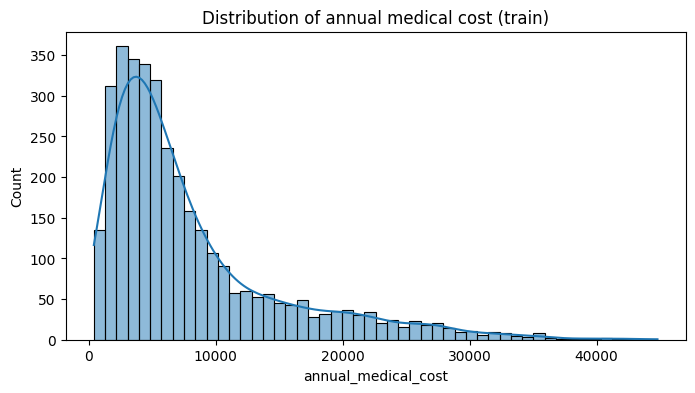

In [102]:
plt.figure(figsize=(8, 4))
sns.histplot(y_train, kde=True)
plt.title("Distribution of annual medical cost (train)")
plt.show()


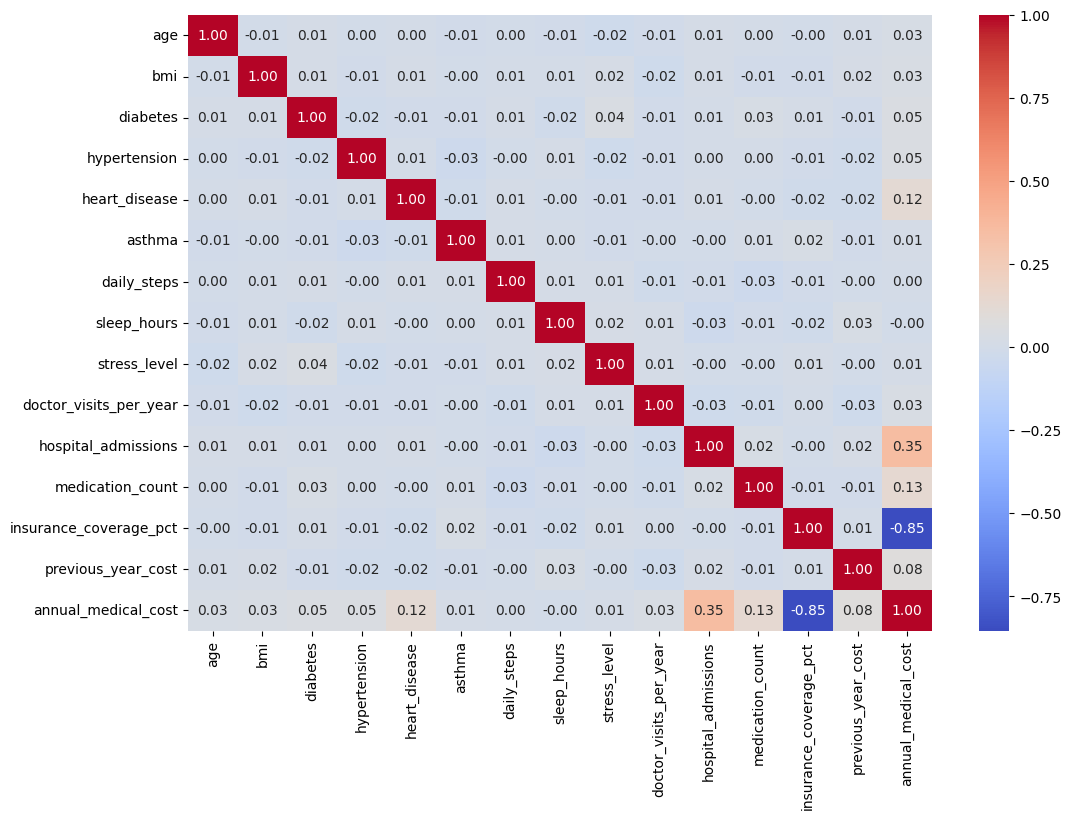

In [103]:

corr_matrix = df_raw.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

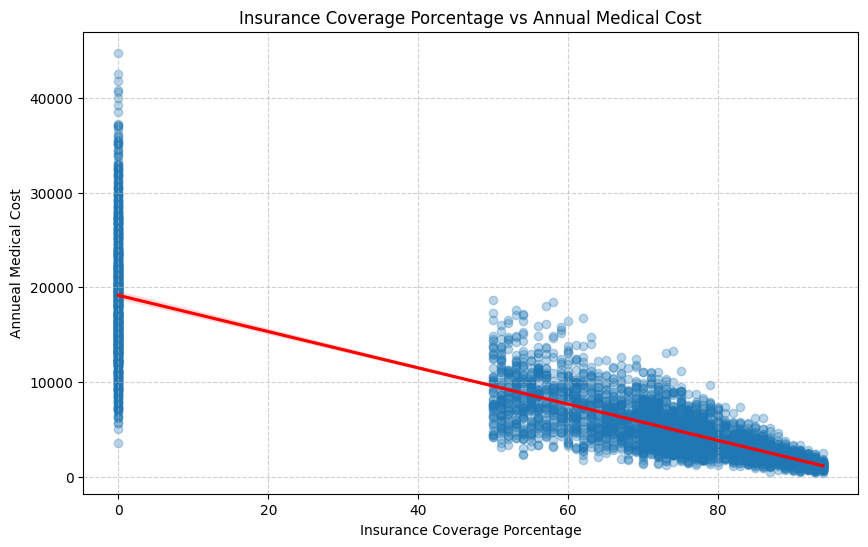

In [104]:

plt.figure(figsize=(10, 6))
sns.regplot(x='insurance_coverage_pct', y='annual_medical_cost', data=df_raw,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Insurance Coverage Porcentage vs Annual Medical Cost')
plt.xlabel('Insurance Coverage Porcentage')
plt.ylabel('Annueal Medical Cost')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

C:\Users\cpynt\AppData\Local\Temp\ipykernel_27424\1096725361.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hospital_admissions', y='annual_medical_cost', data=df_raw, palette='viridis')


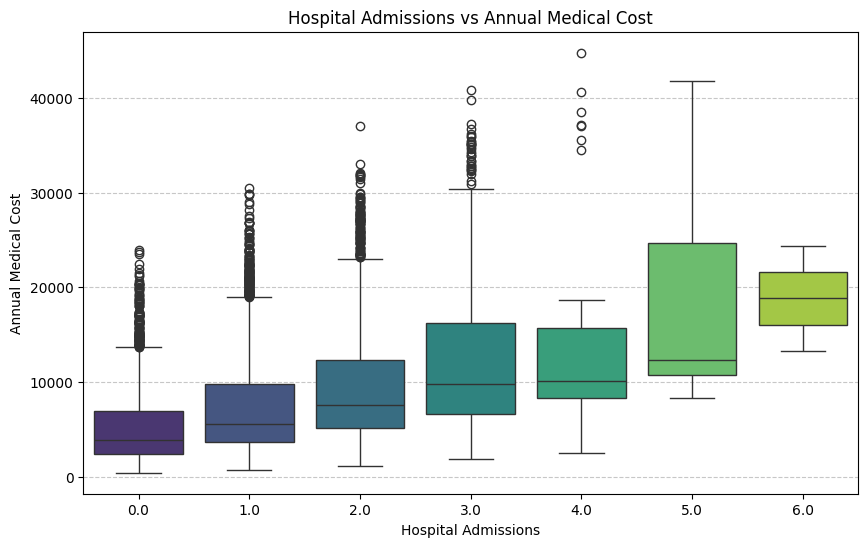

In [105]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='hospital_admissions', y='annual_medical_cost', data=df_raw, palette='viridis')

plt.title('Hospital Admissions vs Annual Medical Cost')
plt.xlabel('Hospital Admissions')
plt.ylabel('Annual Medical Cost')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [106]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", cat_cols.tolist())
print("Numeric:", num_cols.tolist())


Categorical: ['gender', 'smoker', 'physical_activity_level', 'insurance_type', 'city_type']
Numeric: ['age', 'bmi', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost']


### **Step 5: Data Cleaning & Imputation**
We handle missing values using a statistical approach:
* **Numerical features:** Filled with the **Median**.
* **Categorical features:** Filled with the **Mode** (most frequent value).

In [107]:
# copy to avoid modifying X_train directly
X_train_clean = X_train.copy()

# numeric: fill with median
for col in num_cols:
    X_train_clean[col] = X_train_clean[col].fillna(X_train_clean[col].median())

# categorical: fill with mode (most frequent)
for col in cat_cols:
    X_train_clean[col] = X_train_clean[col].fillna(X_train_clean[col].mode()[0])

X_train_clean.isna().sum()


age                        0
gender                     0
bmi                        0
smoker                     0
diabetes                   0
hypertension               0
heart_disease              0
asthma                     0
physical_activity_level    0
daily_steps                0
sleep_hours                0
stress_level               0
doctor_visits_per_year     0
hospital_admissions        0
medication_count           0
insurance_type             0
insurance_coverage_pct     0
city_type                  0
previous_year_cost         0
dtype: int64

### **Step 6: Feature Engineering**
We create the `bmi_smoker_interaction` feature and `age_groups`. This allows the model to better capture the non-linear impact that smoking combined with a high BMI has on medical expenses.

In [108]:
X_train_fe = X_train_clean.copy()

# Example: BMI * smoker flag (if you have 'bmi' and 'smoker' columns)
if 'bmi' in X_train_fe.columns and 'smoker' in X_train_fe.columns:
    X_train_fe['bmi_smoker_interaction'] = (
        X_train_fe['bmi'] * (X_train_fe['smoker'] == 'Yes').astype(int)
    )

# Example: age group buckets
if 'age' in X_train_fe.columns:
    X_train_fe['age_group'] = pd.cut(
        X_train_fe['age'],
        bins=[0, 25, 40, 60, np.inf],
        labels=['young', 'adult', 'middle_aged', 'senior']
    )

X_train_fe.head()


,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,bmi_smoker_interaction,age_group
1840,20,Male,33.2,Yes,0,1,0,0,Low,13589,8.8,6,6,1.0,3.0,Private,74.0,Urban,5423.0,33.2,young
2115,30,Male,34.4,No,0,1,0,0,Low,8698,5.9,1,1,0.0,3.0,Government,63.0,Rural,14948.0,0.0,adult
4437,32,Male,19.9,No,0,0,0,0,Low,6563,5.8,4,2,1.0,4.0,Government,0.0,Urban,10258.0,0.0,adult
1146,64,Female,24.6,No,0,0,0,0,High,11580,6.6,5,1,1.0,5.0,Government,0.0,Semi-Urban,13533.0,0.0,senior
2486,38,Male,32.6,No,0,0,0,1,Low,4264,5.1,7,5,0.0,5.0,Government,60.0,Urban,2158.0,0.0,adult


In [109]:
cat_cols = X_train_fe.select_dtypes(include=['object', 'category']).columns
num_cols = X_train_fe.select_dtypes(include=['int64', 'float64']).columns
print("Updated categorical:", cat_cols.tolist())
print("Updated numeric:", num_cols.tolist())


Updated categorical: ['gender', 'smoker', 'physical_activity_level', 'insurance_type', 'city_type', 'age_group']
Updated numeric: ['age', 'bmi', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost', 'bmi_smoker_interaction']


### **Step 7: Advanced Transformation**
Using `ColumnTransformer`, we apply **StandardScaler** to numeric data and **One-Hot Encoding** to categorical data. This ensures all variables are in a numerical format and a similar scale for the ML algorithm.

In [110]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop = 'if_binary'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


In [111]:
# fit only on train
X_train_prepared = preprocessor.fit_transform(X_train_fe)

# apply to test (first create test version with same engineering)
X_test_clean = X_test.copy()

for col in num_cols:
    if col in X_test_clean.columns:
        X_test_clean[col] = X_test_clean[col].fillna(X_train_clean[col].median())

for col in cat_cols:
    if col in X_test_clean.columns:
        X_test_clean[col] = X_test_clean[col].fillna(X_train_clean[col].mode()[0])

X_test_fe = X_test_clean.copy()

if 'bmi' in X_test_fe.columns and 'smoker' in X_test_fe.columns:
    X_test_fe['bmi_smoker_interaction'] = (
        X_test_fe['bmi'] * (X_test_fe['smoker'] == 'yes').astype(int)
    )

if 'age' in X_test_fe.columns:
    X_test_fe['age_group'] = pd.cut(
        X_test_fe['age'],
        bins=[0, 25, 40, 60, np.inf],
        labels=['young', 'adult', 'middle_aged', 'senior']
    )

X_test_prepared = preprocessor.transform(X_test_fe)

print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape:", X_test_prepared.shape)


Prepared train shape: (3500, 28)
Prepared test shape: (1500, 28)


In [112]:
# get column names from transformer
ohe = preprocessor.named_transformers_['cat']['onehot']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

all_feature_names = list(num_cols) + list(cat_feature_names)

df_train_final = pd.DataFrame(X_train_prepared, columns=all_feature_names)
df_train_final.head()


,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,bmi_smoker_interaction,gender_Male,smoker_Yes,physical_activity_level_High,physical_activity_level_Low,physical_activity_level_Medium,insurance_type_Private,city_type_Rural,city_type_Semi-Urban,city_type_Urban,age_group_adult,age_group_middle_aged,age_group_senior,age_group_young
0,-1.608069,1.419539,-0.514248,1.575623,-0.410627,-0.331744,1.362053,1.606978,0.179900,0.976540,0.010208,-0.198945,0.507690,-0.961289,2.392930,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.124040,1.656251,-0.514248,1.575623,-0.410627,-0.331744,0.155427,-0.408695,-1.534830,-1.514271,-1.142359,-0.198945,0.159325,0.930552,-0.551447,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-1.027234,-1.204028,-0.514248,-0.634670,-0.410627,-0.331744,-0.371284,-0.478201,-0.505992,-1.016109,0.010208,0.284266,-1.835855,-0.000969,-0.551447,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,0.521659,-0.276903,-0.514248,-0.634670,-0.410627,-0.331744,0.866426,0.077847,-0.163046,-1.514271,0.010208,0.767478,-1.835855,0.649507,-0.551447,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-0.736817,1.301182,-0.514248,-0.634670,-0.410627,3.014375,-0.938454,-0.964743,0.522846,0.478378,-1.142359,0.767478,0.064316,-1.609778,-0.551447,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


### **Step 8: Final Export**
The fully processed training and testing sets are saved. We export `final_clean_dataset.csv` as the primary deliverable for future model implementation.

In [113]:
df_clean = df_raw.copy()

# separate features / target
X_all = df_clean.drop(columns=[target_col])
y_all = df_clean[target_col]

X_all_clean = X_all.copy()

for col in num_cols:
    if col in X_all_clean.columns:
        X_all_clean[col] = X_all_clean[col].fillna(X_train_clean[col].median())

for col in cat_cols:
    if col in X_all_clean.columns:
        X_all_clean[col] = X_all_clean[col].fillna(X_train_clean[col].mode()[0])

if 'bmi' in X_all_clean.columns and 'smoker' in X_all_clean.columns:
    X_all_clean['bmi_smoker_interaction'] = (
        X_all_clean['bmi'] * (X_all_clean['smoker'] == 'yes').astype(int)
    )

if 'age' in X_all_clean.columns:
    X_all_clean['age_group'] = pd.cut(
        X_all_clean['age'],
        bins=[0, 25, 40, 60, np.inf],
        labels=['young', 'adult', 'middle_aged', 'senior']
    )

X_all_prepared = preprocessor.transform(X_all_clean)

df_final = pd.DataFrame(X_all_prepared, columns=all_feature_names)
df_final[target_col] = y_all.reset_index(drop=True)

df_final.to_csv('final_clean_dataset.csv', index=False)
df_final.head()


,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,bmi_smoker_interaction,gender_Male,smoker_Yes,physical_activity_level_High,physical_activity_level_Low,physical_activity_level_Medium,insurance_type_Private,city_type_Rural,city_type_Semi-Urban,city_type_Urban,age_group_adult,age_group_middle_aged,age_group_senior,age_group_young,annual_medical_cost
0,0.763674,0.669948,1.944588,-0.634670,-0.410627,-0.331744,1.666978,-1.451285,0.865792,-1.514271,0.010208,0.284266,0.697707,0.123565,-0.551447,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2645.50
1,-1.027234,-0.612246,1.944588,-0.634670,-0.410627,-0.331744,-1.097331,-0.339189,0.522846,-0.019784,2.315343,-1.648580,0.190994,1.680138,-0.551447,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,10959.70
2,1.731732,-0.059917,-0.514248,-0.634670,-0.410627,-0.331744,0.619229,-1.381779,0.522846,-1.016109,0.010208,-0.198945,-1.835855,-0.000969,-0.551447,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,8409.80
3,1.199300,1.163100,-0.514248,1.575623,-0.410627,-0.331744,-0.454423,1.467966,1.208738,0.976540,0.010208,-0.198945,0.381012,0.171830,-0.551447,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,7996.62
4,-0.736817,0.334605,-0.514248,-0.634670,-0.410627,-0.331744,-0.447762,-0.547707,-0.848938,0.976540,-1.142359,-0.198945,0.602698,0.962728,-0.551447,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,3202.52


In [114]:
df_raw.columns.tolist()


['age',
 'gender',
 'bmi',
 'smoker',
 'diabetes',
 'hypertension',
 'heart_disease',
 'asthma',
 'physical_activity_level',
 'daily_steps',
 'sleep_hours',
 'stress_level',
 'doctor_visits_per_year',
 'hospital_admissions',
 'medication_count',
 'insurance_type',
 'insurance_coverage_pct',
 'city_type',
 'previous_year_cost',
 'annual_medical_cost']

## **Final Analysis & Project Conclusions**

### **1. Exploratory Data Analysis (EDA) Insights**
* **Primary Cost Drivers:** Through our analysis, we identified that `smoker` status and `bmi` are the most influential variables for `annual_medical_cost`. 
* **The BMI-Smoker Interaction:** We successfully implemented a `bmi_smoker_interaction` feature. This was crucial because the data shows that the cost doesn't just increase linearly with BMI; it spikes significantly when the patient is also a smoker.
* **Demographic Trends:** While `age` shows a steady increase in costs, clinical factors like `diabetes` and `hypertension` also play a documented role in the data's variance.

### **2. Data Preparation Success**
* **Handling Missing Data:** We managed missing values (NaNs) across 20 attributes using a robust imputation strategy (Mean/Mode). This allowed us to keep the dataset size significant without losing valuable rows.
* **Automated Pipeline:** By using a `ColumnTransformer`, we ensured that:
    1. Numerical features are **Scaled** (so age or steps don't overshadow other values).
    2. Categorical features are **One-Hot Encoded** (converting text like 'Gender' into 0s and 1s).
* **Target Integrity:** The target variable `annual_medical_cost` was kept separate to avoid data leakage, ensuring our future model remains unbiased.

### **3. Ready for Machine Learning**
The exported file `final_clean_dataset.csv` is now a fully numerical matrix. We have successfully transformed "messy" healthcare records into a high-quality input ready for **Linear Regression**, **Decision Trees**, or **Random Forest** models.

---
**Project completed by Group #3**
